In [6]:
#zadanie 1z

import pandas as pd
import numpy as np

df = pd.read_csv('zamowienia.csv', sep=';')

print(df.isna().sum())

df_braki = df.copy()

indeksy_sprzedawca = df_braki.sample(frac=0.10, random_state=42).index
df_braki.loc[indeksy_sprzedawca, 'Sprzedawca'] = 'BRAK'

indeksy_id = df_braki.sample(frac=0.05, random_state=42).index
df_braki.loc[indeksy_id, 'idZamowienia'] = np.nan

indeksy_data = df_braki.sample(frac=0.20, random_state=42).index
df_braki.loc[indeksy_data, 'Data zamowienia'] = np.nan

indeksy_utarg = df_braki.sample(frac=0.15, random_state=42).index
df_braki.loc[indeksy_utarg, 'Utarg'] = np.nan


print("Liczba wartości np.nan: ")
print(df_braki.isna().sum())

ile_tekst_brak = (df_braki['Sprzedawca'] == 'BRAK').sum()
print(f"\nLiczba wstawionych tekstów brak: {ile_tekst_brak}")

Kraj               0
Sprzedawca         0
Data zamowienia    0
idZamowienia       0
Utarg              0
dtype: int64
Liczba wartości np.nan: 
Kraj                 0
Sprzedawca           0
Data zamowienia    160
idZamowienia        40
Utarg              120
dtype: int64

Liczba wstawionych tekstów brak: 80


In [9]:
#zadanie 2

df_braki['idZamowienia'] = df_braki['idZamowienia'].fillna(0)

df_braki['Data zamowienia'] = df_braki['Data zamowienia'].ffill()

srednia_dla_kraju = df_braki.groupby('Kraj')['Utarg'].transform('mean')

df_braki['Utarg'] = df_braki['Utarg'].fillna(srednia_dla_kraju)

print(df_braki.isna().sum())

Kraj               0
Sprzedawca         0
Data zamowienia    0
idZamowienia       0
Utarg              0
dtype: int64


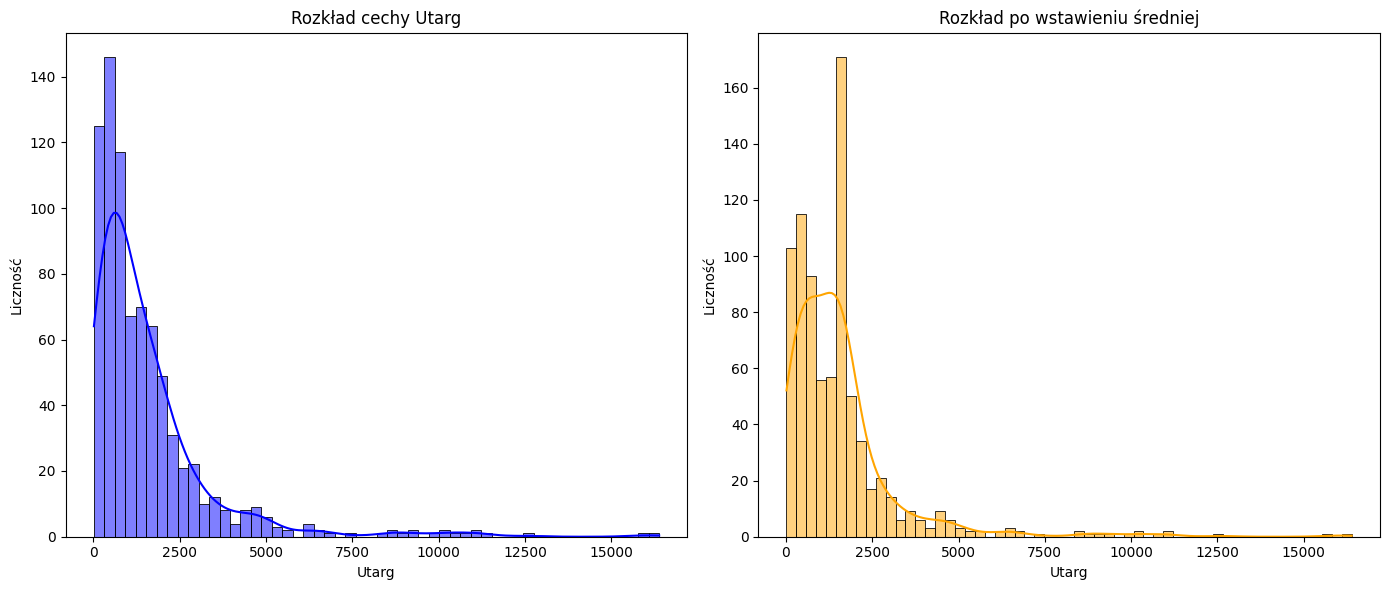

In [12]:
#zadanie 3

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x='Utarg', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Rozkład cechy Utarg')
axes[0].set_xlabel('Utarg')
axes[0].set_ylabel('Liczność')

sns.histplot(data=df_braki, x='Utarg', kde=True, ax=axes[1], color='orange')
axes[1].set_title('Rozkład po wstawieniu średniej')
axes[1].set_xlabel('Utarg')
axes[1].set_ylabel('Liczność')

plt.tight_layout()

plt.show()

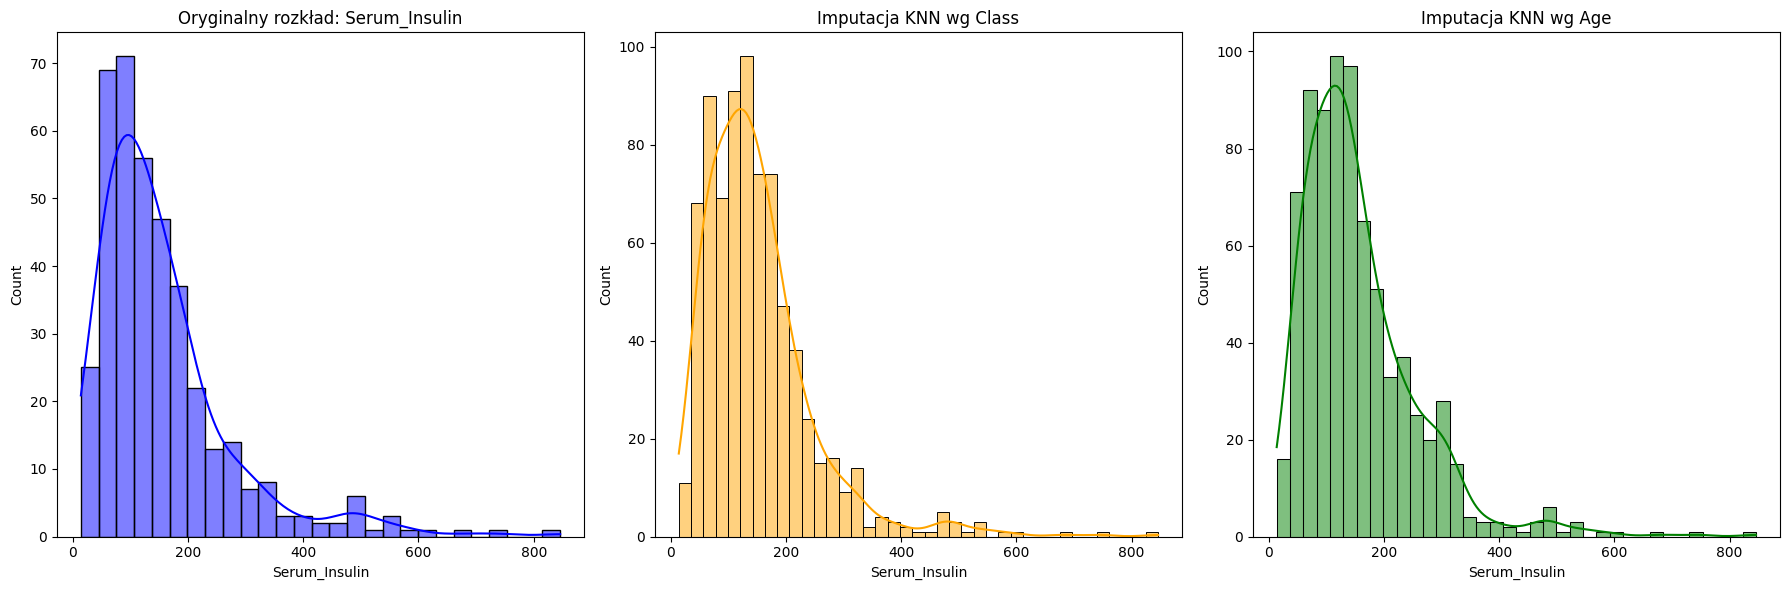

In [16]:
#zadanie 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

df = pd.read_csv('Diabetes Missing Data.csv')

df_class = df.copy()
df_age = df.copy()

imputer = KNNImputer(n_neighbors=5)

kolumny_numeryczne = df.select_dtypes(include=[np.number]).columns.tolist()


for nazwa_klasy, grupa in df_class.groupby('Class'):
    uzupelnione = imputer.fit_transform(grupa[kolumny_numeryczne])

    df_class.loc[grupa.index, kolumny_numeryczne] = uzupelnione


przedzialy = [0, 18, 30, 50, np.inf]
etykiety = ['<18', '18_29', '30_49', '50+']
df_age['Age_Group'] = pd.cut(df_age['Age'], bins=przedzialy, labels=etykiety, right=False)


for nazwa_grupy, grupa in df_age.groupby('Age_Group', observed=False):
    if not grupa.empty:
        kolumny_do_imputacji = [k for k in kolumny_numeryczne if k != 'Age_Group']
        uzupelnione = imputer.fit_transform(grupa[kolumny_do_imputacji])
        df_age.loc[grupa.index, kolumny_do_imputacji] = uzupelnione


cecha = 'Serum_Insulin'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(data=df, x=cecha, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Oryginalny rozkład: {cecha}')

sns.histplot(data=df_class, x=cecha, kde=True, ax=axes[1], color='orange')
axes[1].set_title(f'Imputacja KNN wg Class')

sns.histplot(data=df_age, x=cecha, kde=True, ax=axes[2], color='green')
axes[2].set_title(f'Imputacja KNN wg Age')

plt.tight_layout()
plt.show()